# Experiment 4: Binary Classification using Linear and Kernel-Based Models
### Spambase Dataset — Logistic Regression vs SVM

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np

from utils import load_dataset, dataset_info, print_shape
from eda import perform_classification_eda, plot_classification_eda_summary
from preprocessing import preprocess_data
from classification import train_classification
from hyperparameter import grid_search, randomized_search
from metrics import classification_metrics, compare_classification_models
from validation import compare_classification_cross_validation
from timing import measure_time, compare_training_prediction_time
from visualization import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_classification_scores,
    plot_classification_cv_scores
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = load_dataset("spambase.csv")

print_shape(df)
df.head()

Rows: 4601
Columns: 58


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
dataset_info(df)

DATASET INFORMATION

Shape: (4601, 58)

Columns:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B

## Exploratory Data Analysis

CLASSIFICATION EDA
Shape: (4601, 58)

Missing Values:
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs    

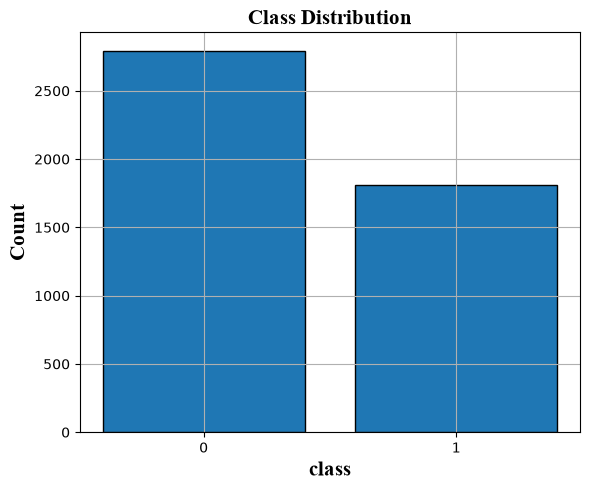

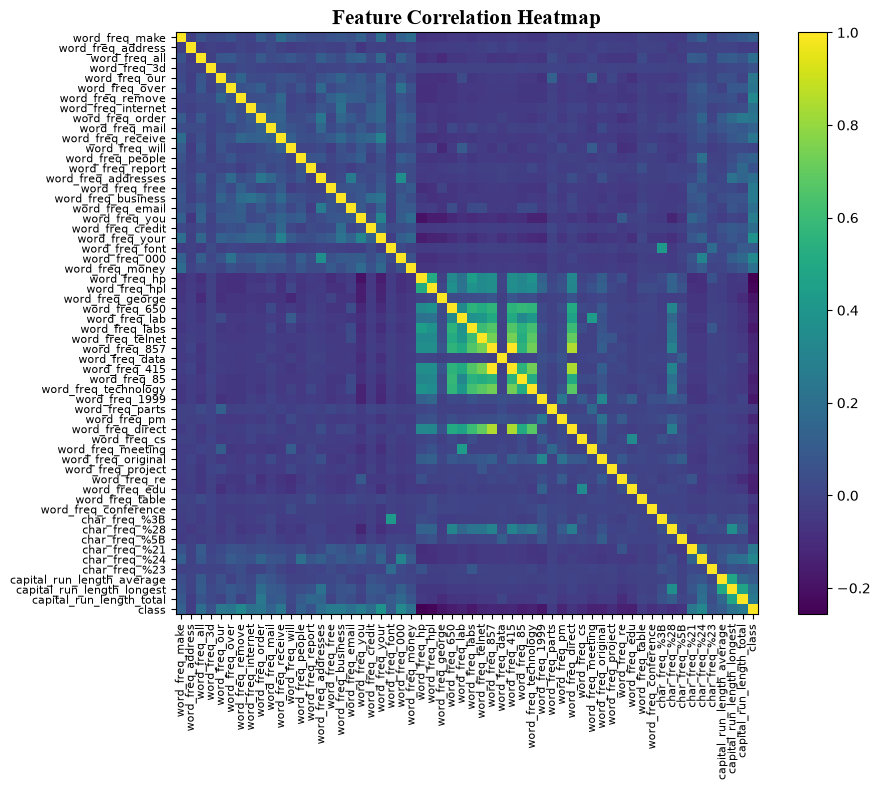


Target Correlation:
class                         1.000000
word_freq_your                0.383234
word_freq_000                 0.334787
word_freq_remove              0.332117
char_freq_%24                 0.323629
word_freq_you                 0.273651
word_freq_free                0.263215
word_freq_business            0.263204
capital_run_length_total      0.249164
word_freq_our                 0.241920
char_freq_%21                 0.241888
word_freq_receive             0.234529
word_freq_over                0.232604
word_freq_order               0.231551
word_freq_money               0.216111
capital_run_length_longest    0.216097
word_freq_internet            0.206808
word_freq_email               0.204208
word_freq_all                 0.196988
word_freq_addresses           0.195902
word_freq_credit              0.189761
word_freq_mail                0.138962
word_freq_people              0.132927
word_freq_make                0.126208
capital_run_length_average    0.109999
word

In [4]:
TARGET_COLUMN = "class"

perform_classification_eda(df, TARGET_COLUMN)

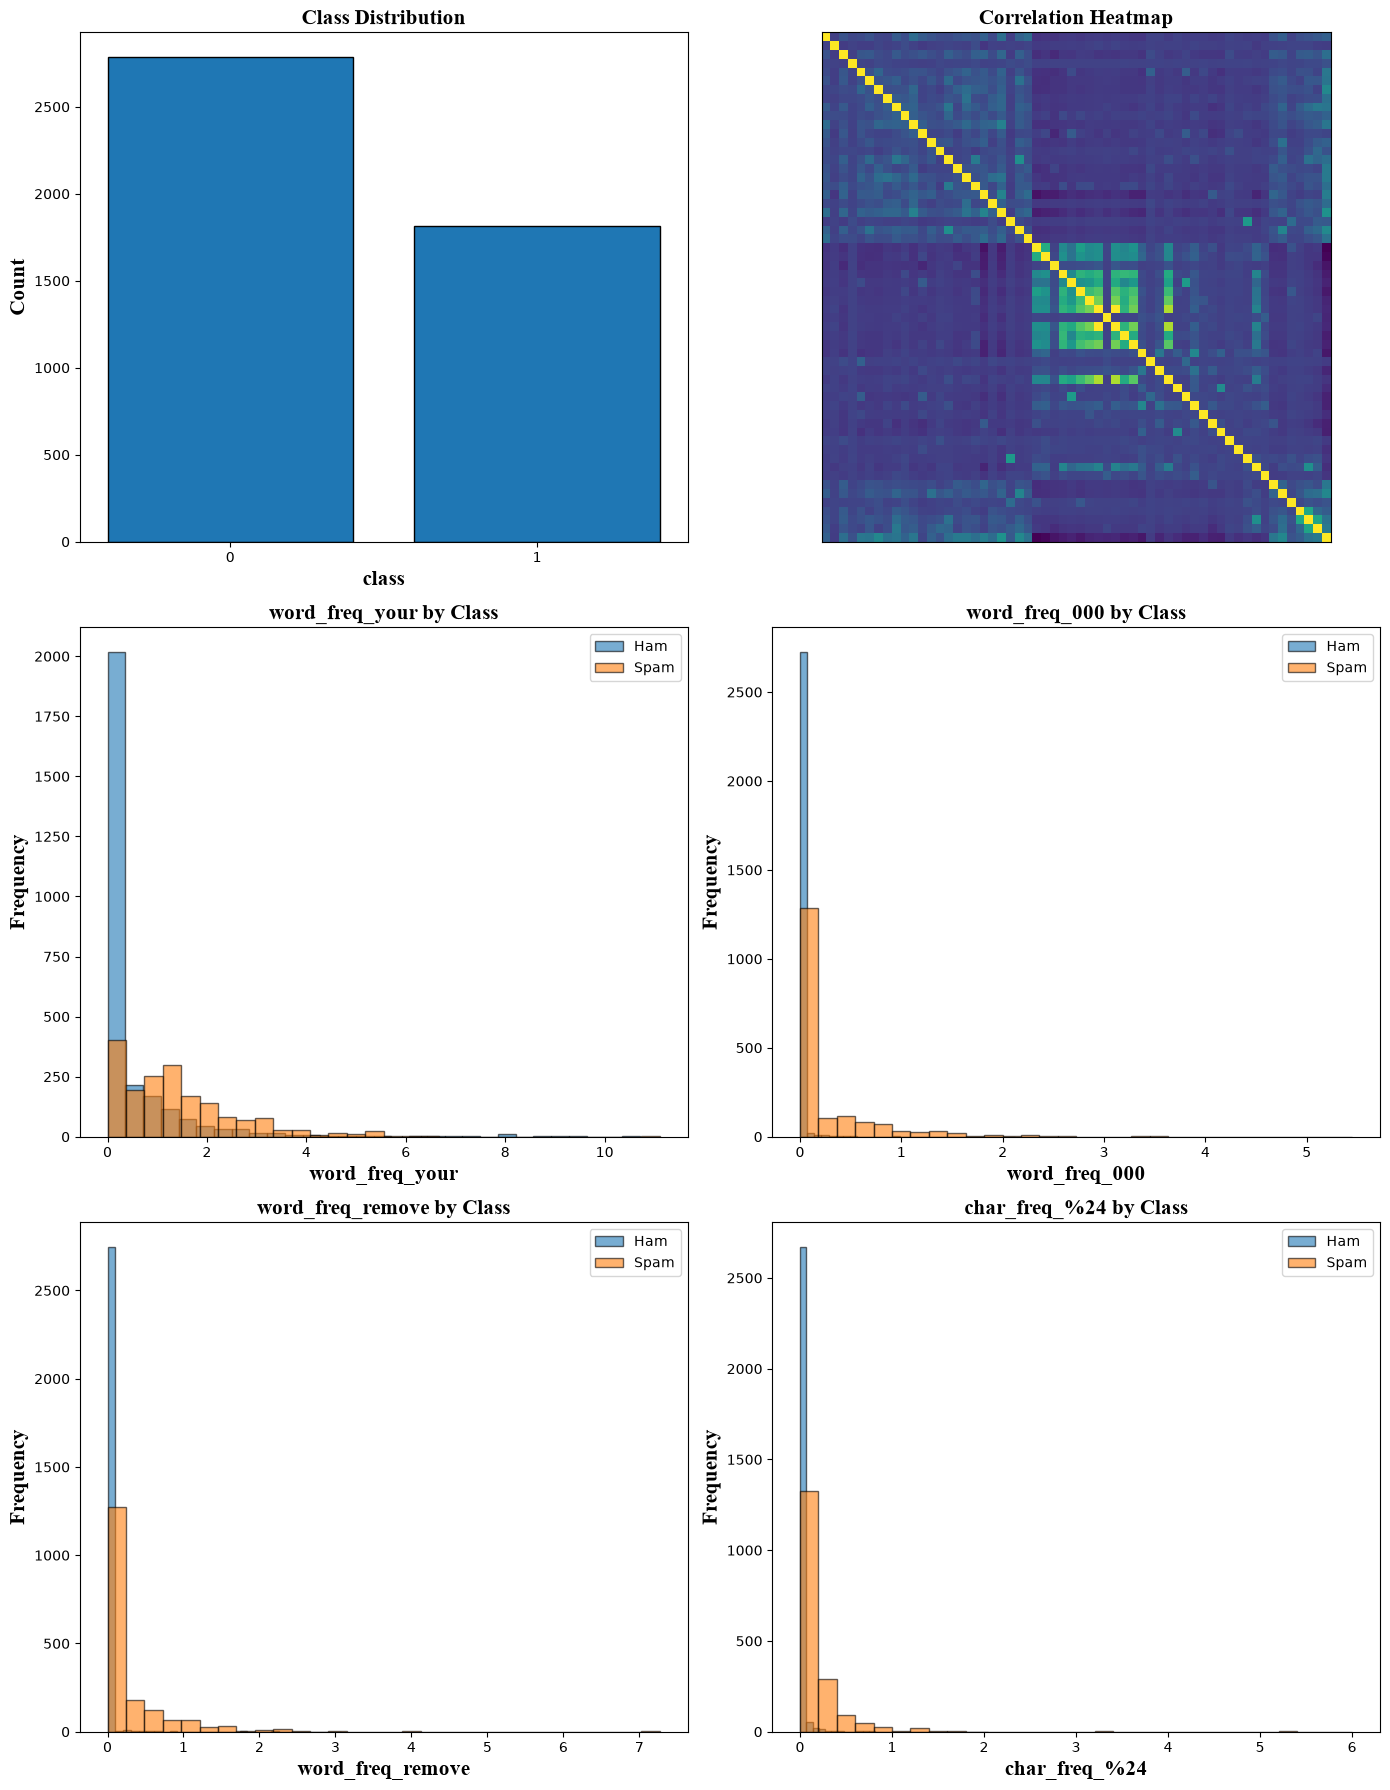

In [5]:
plot_classification_eda_summary(df, TARGET_COLUMN)

## Data Preprocessing
Standardize features, split into train/test sets. Spambase has no categorical
columns and no missing values, so `preprocess_data` runs cleanly with scaling enabled.

In [6]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    preprocessor,
    feature_names
) = preprocess_data(
    df,
    target_column=TARGET_COLUMN,
    test_size=0.2,
    random_state=42,
    scale=True
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training samples: 3368
Testing samples: 842
Number of features: 57


## Baseline Logistic Regression

Accuracy : 0.9145
Precision: 0.9284
Recall   : 0.8663
F1 Score : 0.8963


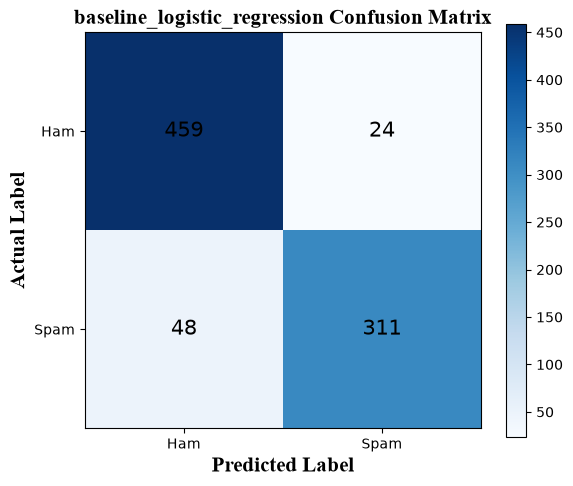

In [7]:
baseline_lr = train_classification(
    X_train,
    y_train,
    algorithm="logistic_regression"
)

baseline_lr_results = classification_metrics(
    baseline_lr,
    X_test,
    y_test,
    model_name="Baseline Logistic Regression"
)

print("Accuracy :", round(baseline_lr_results["Accuracy"], 4))
print("Precision:", round(baseline_lr_results["Precision"], 4))
print("Recall   :", round(baseline_lr_results["Recall"], 4))
print("F1 Score :", round(baseline_lr_results["F1 Score"], 4))

plot_confusion_matrix(
    y_test,
    baseline_lr_results["Predictions"],
    model_name="baseline_logistic_regression"
)

## Logistic Regression Hyperparameter Tuning
Search space: `penalty` ∈ {L1, L2}, `C` ∈ {0.01, 0.1, 1, 10, 100}, `solver` ∈ {liblinear, saga}.
Grid Search with 5-fold cross validation, scored on accuracy.

In [8]:
lr_param_grid = [
    {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"]
    },
    {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["liblinear", "saga"]
    }
]

lr_search = grid_search(
    model=LogisticRegression(max_iter=5000, random_state=42),
    parameters=lr_param_grid,
    X_train=X_train,
    y_train=y_train,
    cv=5,
    scoring="accuracy"
)

best_lr = lr_search.best_estimator_
best_lr_params = lr_search.best_params_
best_lr_cv_score = lr_search.best_score_

GRID SEARCH RESULTS
Best Parameters: {'C': 100, 'penalty': 'l1', 'solver': 'saga'}
Best Score: 0.9231


Best Parameters: {'C': 100, 'penalty': 'l1', 'solver': 'saga'}
Best CV Accuracy: 0.9231

Test Accuracy : 0.9204
Test Precision: 0.932
Test Recall   : 0.8774
Test F1 Score : 0.9039


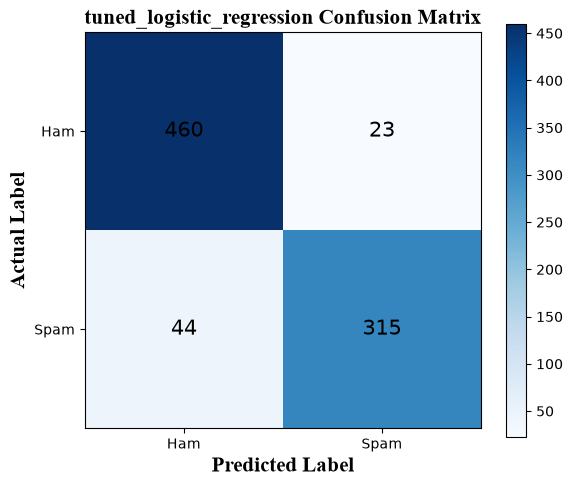

In [9]:
tuned_lr_results = classification_metrics(
    best_lr,
    X_test,
    y_test,
    model_name="Tuned Logistic Regression"
)

print("Best Parameters:", best_lr_params)
print("Best CV Accuracy:", round(best_lr_cv_score, 4))
print()
print("Test Accuracy :", round(tuned_lr_results["Accuracy"], 4))
print("Test Precision:", round(tuned_lr_results["Precision"], 4))
print("Test Recall   :", round(tuned_lr_results["Recall"], 4))
print("Test F1 Score :", round(tuned_lr_results["F1 Score"], 4))

plot_confusion_matrix(
    y_test,
    tuned_lr_results["Predictions"],
    model_name="tuned_logistic_regression"
)

## SVM — Kernel-wise Comparison
Training SVM with Linear, Polynomial, RBF, and Sigmoid kernels (default hyperparameters)
to compare baseline kernel behavior before tuning.

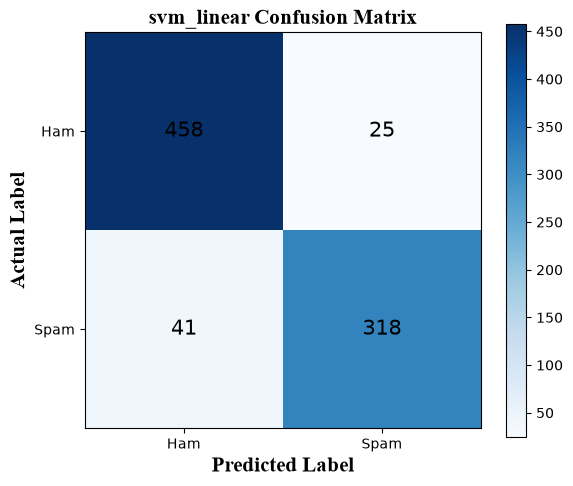

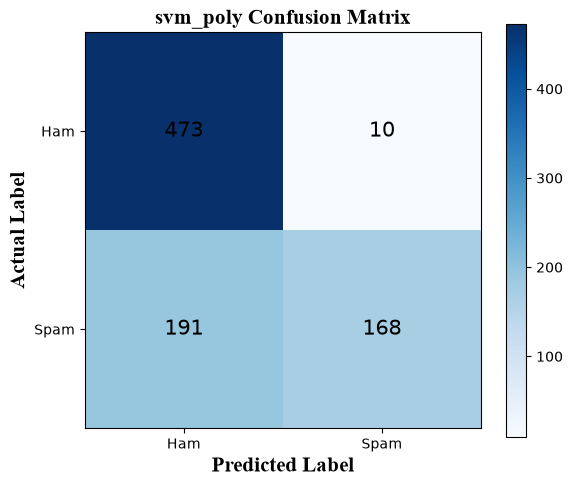

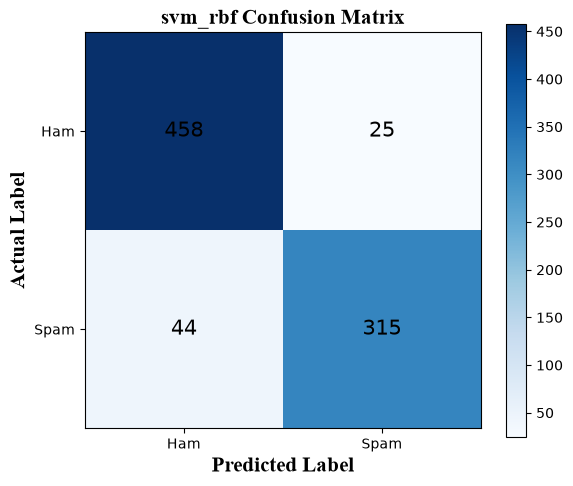

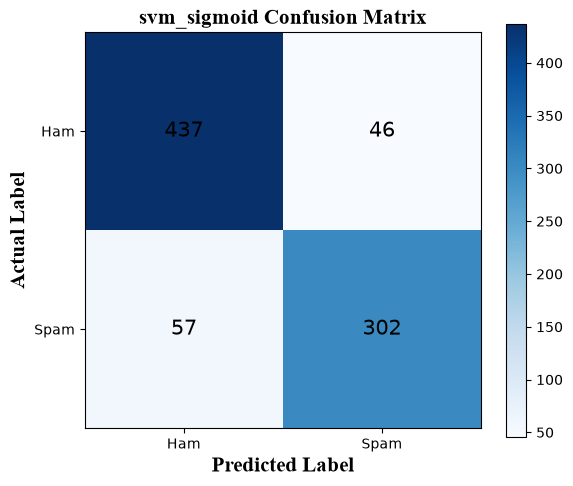

,Kernel,Accuracy,F1 Score
0,linear,0.921615,0.905983
1,poly,0.761283,0.625698
2,rbf,0.918052,0.901288
3,sigmoid,0.877672,0.854314


In [10]:
kernels = ["linear", "poly", "rbf", "sigmoid"]

svm_kernel_models = {}
svm_kernel_results = []

for kernel in kernels:

    model = train_classification(
        X_train,
        y_train,
        algorithm="svm",
        kernel=kernel
    )

    svm_kernel_models[kernel] = model

    result = classification_metrics(
        model,
        X_test,
        y_test,
        model_name=kernel
    )

    svm_kernel_results.append({
        "Kernel": kernel,
        "Accuracy": result["Accuracy"],
        "F1 Score": result["F1 Score"]
    })

    plot_confusion_matrix(
        y_test,
        result["Predictions"],
        model_name=f"svm_{kernel}"
    )

svm_kernel_df = pd.DataFrame(svm_kernel_results)
svm_kernel_df

In [11]:
svm_timing_df = compare_training_prediction_time(
    svm_kernel_models,
    X_train,
    y_train,
    X_test
)

TRAINING AND PREDICTION TIME COMPARISON
     Model  Training Time  Prediction Time
0  sigmoid       0.752729         0.024375
1      rbf       1.097916         0.113870
2     poly       1.126711         0.035764
3   linear       1.202151         0.010924


## SVM Hyperparameter Tuning
Search space: `kernel` ∈ {linear, poly, rbf, sigmoid}, `C` ∈ {0.1, 1, 10, 100},
`gamma` ∈ {scale, auto}, `degree` ∈ {2, 3, 4} (used only for polynomial kernel).

In [12]:
svm_param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf", "sigmoid"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"]
    },
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"],
        "degree": [2, 3, 4]
    }
]

svm_search = grid_search(
    model=SVC(probability=True, random_state=42),
    parameters=svm_param_grid,
    X_train=X_train,
    y_train=y_train,
    cv=5,
    scoring="accuracy",
)

best_svm = svm_search.best_estimator_
best_svm_params = svm_search.best_params_
best_svm_cv_score = svm_search.best_score_

GRID SEARCH RESULTS
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score: 0.9299


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9299

Test Accuracy : 0.9133
Test Precision: 0.9206
Test Recall   : 0.8719
Test F1 Score : 0.8956


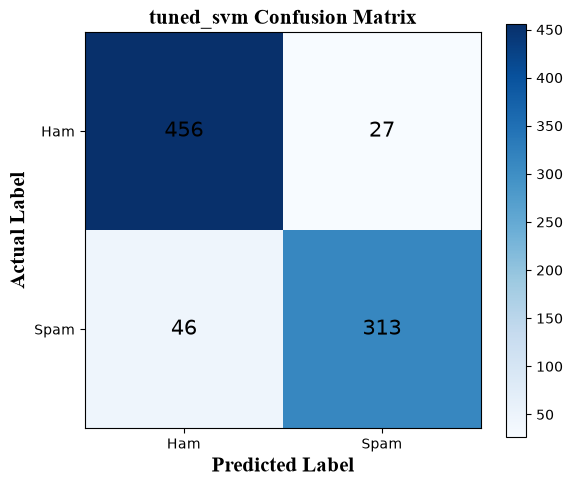

In [13]:
tuned_svm_results = classification_metrics(
    best_svm,
    X_test,
    y_test,
    model_name="Tuned SVM"
)

print("Best Parameters:", best_svm_params)
print("Best CV Accuracy:", round(best_svm_cv_score, 4))
print()
print("Test Accuracy :", round(tuned_svm_results["Accuracy"], 4))
print("Test Precision:", round(tuned_svm_results["Precision"], 4))
print("Test Recall   :", round(tuned_svm_results["Recall"], 4))
print("Test F1 Score :", round(tuned_svm_results["F1 Score"], 4))

plot_confusion_matrix(
    y_test,
    tuned_svm_results["Predictions"],
    model_name="tuned_svm"
)

## Final Model Comparison — Logistic Regression vs SVM

CLASSIFICATION MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.920428   0.931953  0.877437  0.903874
1                  SVM  0.913302   0.920588  0.871866  0.895565


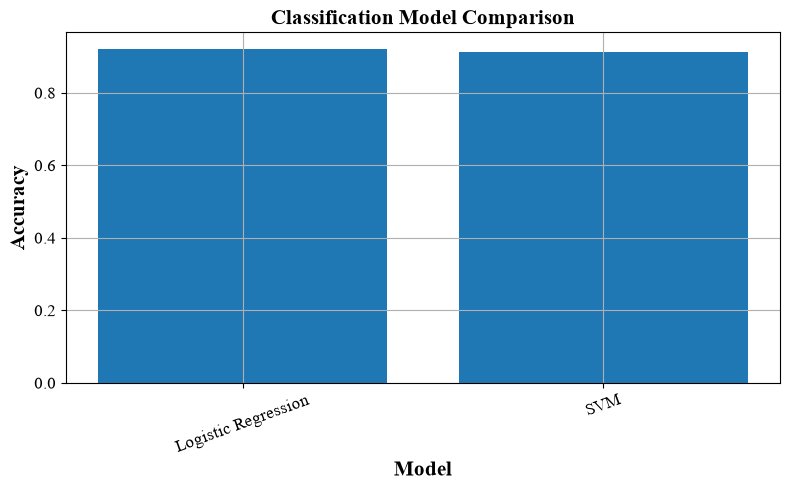

In [14]:
final_models = {
    "Logistic Regression": best_lr,
    "SVM": best_svm
}

comparison_df = compare_classification_models(
    final_models,
    X_test,
    y_test
)

plot_classification_scores(
    comparison_df["Model"],
    comparison_df["Accuracy"],
    ylabel="Accuracy"
)

In [15]:
final_timing_df = compare_training_prediction_time(
    final_models,
    X_train,
    y_train,
    X_test
)

TRAINING AND PREDICTION TIME COMPARISON
                 Model  Training Time  Prediction Time
0                  SVM       0.947880         0.085542
1  Logistic Regression       8.678014         0.000432


## ROC Curve Comparison

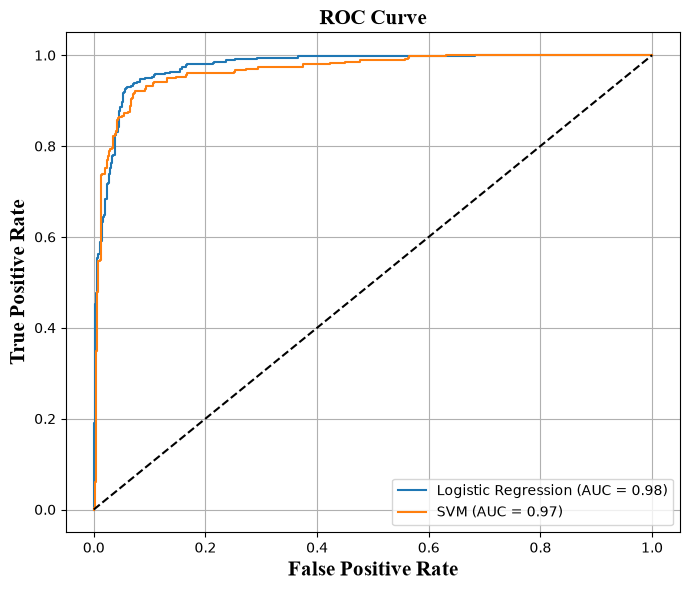

In [16]:
model_probabilities = {
    "Logistic Regression": best_lr.predict_proba(X_test)[:, 1],
    "SVM": best_svm.predict_proba(X_test)[:, 1]
}

plot_roc_curve(
    model_probabilities,
    y_test
)

## 5-Fold Cross Validation

5-FOLD CROSS VALIDATION PERFORMANCE (CLASSIFICATION)
                 Model  Average Accuracy   Std Dev
0  Logistic Regression          0.923040  0.007564
1                  SVM          0.926128  0.011075


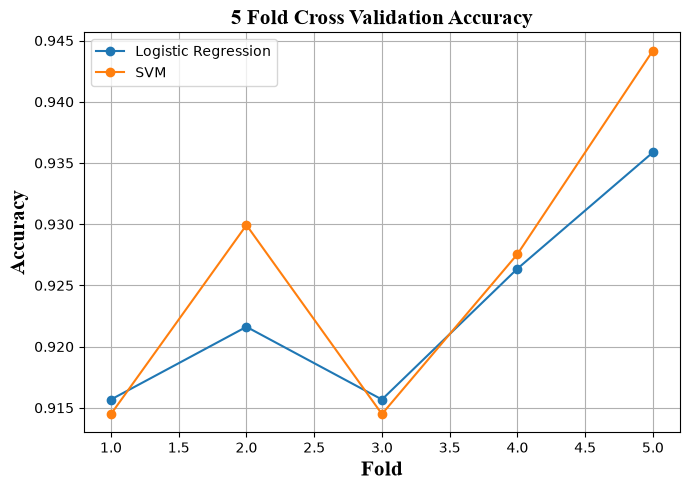

In [17]:
X_full = np.vstack([X_train, X_test])
y_full = pd.concat([y_train, y_test])

cv_summary_df, fold_scores = compare_classification_cross_validation(
    final_models,
    X_full,
    y_full,
    folds=5
)

plot_classification_cv_scores(fold_scores)

## Summary

- Baseline vs tuned Logistic Regression accuracy improvement recorded above.
- Best Logistic Regression parameters: printed in Cell 13.
- SVM kernel-wise comparison (Linear, Polynomial, RBF, Sigmoid): Cell 15.
- Best SVM parameters after tuning: printed in Cell 19.
- Final comparison, ROC curves, and 5-fold CV results are used directly for the
  Hyperparameter Tuning Results, Model Performance, and Cross-Validation tables
  in the lab report.